# Worksheet: Introduction to Recurrent Neural Networks

**Topic:** Recurrent Neural Networks, Sliding Windows, and Stock Forecasting

This interactive worksheet introduces sequence data, sliding windows, recurrent neuron outputs, and a simple RNN implementation using a stock-style dataset.

## Learning goals

By the end of this worksheet, students should be able to:

1. Explain why order matters in sequence data.
2. Create supervised learning examples using a sliding window.
3. Explain the meaning of window size and horizon.
4. Compute the output of a simple recurrent neuron.
5. Interpret the hidden state in an RNN.
6. Build and evaluate a simple RNN for stock-price forecasting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

# 1. What is sequence data?

A **sequence** is an ordered collection of values. In sequence data, order matters.

Examples:
- daily stock prices
- weekly inventory
- monthly sales
- customer clickstream behavior
- words in a sentence

A standard feed-forward neural network treats observations as independent, but an RNN is designed to process observations over time.


If we use lagged values ($S_{t-5}, S_{t-4}, S_{t-3}, ..., S_{t-1}$ are predictors of $S_t$). RF, XGBoost, Feed-forward architectures assume that these values of S are independent. We need a model that accounts for trends, dependence for better predictions.

## Practice 1A: Concept check

1. Why is a stock-price series a sequence?  


**Your response here:**  
1.  Because data is ordered and the order matters.


---

# 2. Sliding window method

A sliding window turns a time series into a supervised learning dataset.

Example:

Series: `[10, 12, 13, 15, 18, 20]`  
Window size = 3  
Horizon = 1

| Input window | Target |
|---|---|
| [10, 12, 13] | 15 |
| [12, 13, 15] | 18 |
| [13, 15, 18] | 20 |

## Practice 2A: Sliding window by hand

Given the sequence:

`[100, 102, 101, 105, 107, 110]`

Use:
- window size = 3
- horizon = 1

Fill in the windows and targets.

| Input window | Target |
|---|---|
| [100, 102, 101] | 105 |
| [102, 101, 105] | 107 |
| [101, 105, 107] | 110 |


Use:
- window size = 3
- horizon = 2

Fill in the windows and targets.

| Input window | Target |
|---|---|
| [100, 102, 101] | 107 |
| [102, 101, 105] | 110 |


Use:
- window size = 4
- horizon = 1

Fill in the windows and targets.

| Input window | Target |
|---|---|
| [100, 102, 101, 105] | 107 |
| [102, 101, 105, 107] | 110 |


Tensorflow has a function called `TimeSeriesGenerator` that does this.

## Practice 2B: Code the sliding-window function

In [2]:
import numpy as np

def make_windows(series, window_size, horizon=1):
    X = []
    y = []

    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size + horizon - 1])

    return np.array(X), np.array(y)

In [3]:
# Self-check
series = np.array([100, 102, 101, 105, 107, 110])
X, y = make_windows(series, window_size=2, horizon=3)

print("X:")
print(X)
print("y:")
print(y)


X:
[[100 102]
 [102 101]]
y:
[107 110]


In [4]:
# Self-check
series = np.array([100, 102, 101, 105, 107, 110, 111, 112, 113])
X, y = make_windows(series, window_size=2, horizon=3)

print("X:")
print(X)
print("y:")
print(y)


X:
[[100 102]
 [102 101]
 [101 105]
 [105 107]
 [107 110]]
y:
[107 110 111 112 113]


In [5]:
# For RNNs and CNNs we use 3-way tensors: e.g. above X : (5 x 2), but we want X: (5 x 2 x 1)
# Input(shape = (5,2,1))
# For an RNN, reshape X to have shape:

X_rnn = X.reshape((X.shape[0], X.shape[1], 1))

print(X_rnn.shape)

(5, 2, 1)


## Practice 2C: Horizon

Suppose:

`[100, 102, 101, 105, 107, 110, 115]`

Window size = 3  
Horizon = 2

The first input window is `[100, 102, 101]`.

What is the target?

107 is the target for this input window.

In [6]:
# Self-check
series = np.array([100, 102, 101, 105, 107, 110, 115])
X_check, y_check = make_windows(series, window_size=3, horizon=2)

print("X:")
print(X_check)  ## X needs to be reshaped as a tensor for RNNs
print("y:")
print(y_check)  ## y is a vector y[0] is the target of the first obs

X:
[[100 102 101]
 [102 101 105]
 [101 105 107]]
y:
[107 110 115]


---

# 3. Multivariate sequences

A sequence can have more than one feature at each time step.

For example, a stock dataset might include:
- closing price
- daily return
- trading volume

RNN input shape is usually:

`(samples, time_steps, features)`

## Practice 3A: Shape interpretation

Suppose:
- 500 windows
- 20 time steps per window
- 3 features per time step

What is the RNN input shape?

In [7]:
(500, 20, 3)  ## for Input shape

(500, 20, 3)

## Practice 3B: Multivariate window function

In [8]:
def make_multivariate_windows(df, feature_cols, target_col, window_size, horizon=1):
    X = []
    y = []

    values = df[feature_cols].values
    target = df[target_col].values

    for i in range(len(values) - window_size - horizon + 1):
        X.append(values[i : i + window_size])
        y.append(target[i + window_size + horizon - 1])

    return np.array(X), np.array(y)

In [9]:
# Self-check for multivariate windows
data = {
    'price': [10, 11, 12, 13, 14, 15],
    'volume': [100, 110, 120, 130, 140, 150]
}

## For Price we would have
# [10, 11] ---> 12
# [11, 12] ---> 13
# ...............

## For Volume we would have
# [100, 110]
# [110, 120]
## ..............


## In multivariate we still have a single y (so we dont need to predict the price and the volume)
## (4 windows x 2 lags x 2 features)


df = pd.DataFrame(data)

# window_size=2, horizon=1, features=['price', 'volume'], target='price'
X_multi, y_multi = make_multivariate_windows(
    df,
    feature_cols=['price', 'volume'],
    target_col='price',
    window_size=2,
    horizon=1
)

print("Multivariate X shape:", X_multi.shape)
print("First window in X:\n", X_multi[0])
print("First target in y:", y_multi[0])

Multivariate X shape: (4, 2, 2)
First window in X:
 [[ 10 100]
 [ 11 110]]
First target in y: 12


In [10]:
X_multi

array([[[ 10, 100],
        [ 11, 110]],

       [[ 11, 110],
        [ 12, 120]],

       [[ 12, 120],
        [ 13, 130]],

       [[ 13, 130],
        [ 14, 140]]])

In [11]:
y_multi

array([12, 13, 14, 15])

---

# 4. Recurrent neuron output

A simple RNN neuron uses the current input and the previous hidden state.

$h_t = \tanh(w_x x_t + w_h h_{t-1} + b)$

where:
- $x_t$ is the current input
- $h_{t-1}$ is the previous hidden state
- $h_t$ is the new hidden state

## Practice 4A: One-step recurrent neuron

Suppose:

- $x_t = 2.0$   -------> a value at time t (current) of seq
- $h_{t-1} = 0.5$ -------> rolling weighted avg (at time t-1)
- $w_x = 0.8$  --------> weight of the current value
- $w_h = 0.4$  --------> weight to rolling weighted average
- $b = -0.1$  --------> bias (add or subract out of the total sum)

Compute:

$h_t = \tanh(w_x x_t + w_h h_{t-1} + b)$

In [12]:
## this is a single time step
x_t = 2.0
h_prev = 0.5 ## hidden state
w_x = 0.8
w_h = 0.4
b = -0.1

# TODO
h_t = np.tanh(0.8*2.0 + 0.4 * 0.5 - 0.1)

print("h_t =", h_t)

h_t = 0.935409070603099


In [13]:
ht = np.tanh(w_x * x_t + w_h * h_prev + b)
print(ht)

0.935409070603099


## Practice 4B: Recurrent neuron across a sequence

Use the sequence:

`[1.0, 2.0, -1.0]`

Initial hidden state = 0.

In [14]:
## step 1:
h = 0 ## hidden state
w_x = 0.8
w_h = 0.4
b = -0.1

h = np.tanh(w_x * 1.0 + w_h * h + b)
print("h_1 =", h)

h_1 = 0.6043677771171635


In [15]:
## step 2:

w_x = 0.8
w_h = 0.4
b = -0.1

h = np.tanh(w_x * 2.0 + w_h * h + b)
print("h_2 =", h)

h_2 = 0.9404289270915237


In [16]:
## step 3:

w_x = 0.8
w_h = 0.4
b = -0.1

h = np.tanh(w_x * -1.0 + w_h * h + b)
print("h_3 =", h)

h_3 = -0.4806493957651368


In [17]:
sequence = np.array([1.0, 2.0, -1.0])
h = 0.0
hidden_states = []

for x_val in sequence:
    h = np.tanh(w_x * x_val + w_h * h + b)
    hidden_states.append(h)

print("Hidden states:", hidden_states)

Hidden states: [np.float64(0.6043677771171635), np.float64(0.9404289270915237), np.float64(-0.4806493957651368)]


In [18]:
## if you need the whole seq: seq to seq
hidden_states

[np.float64(0.6043677771171635),
 np.float64(0.9404289270915237),
 np.float64(-0.4806493957651368)]

In [19]:
## if you need to predict the next day price: seq2vec
hidden_states[-1]

np.float64(-0.4806493957651368)

## Practice 4C: Interpretation

Why does the hidden state matter in an RNN?

**Your response here:**  
-

---

# 5. Fit an ML Regressors and RNN to stock data


In [20]:
import yfinance as yf

## bitcoin price in usd
BTC_Ticker = yf.Ticker("BTC-USD")
BTC_Data = BTC_Ticker.history(period="max")
BTC_Data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0


In [21]:
## Let's use Close as our sequence
BTC_Close = BTC_Data['Close']
BTC_Close.head()

,Close
Date,
2014-09-17 00:00:00+00:00,457.334015
2014-09-18 00:00:00+00:00,424.440002
2014-09-19 00:00:00+00:00,394.795990
2014-09-20 00:00:00+00:00,408.903992
2014-09-21 00:00:00+00:00,398.821014


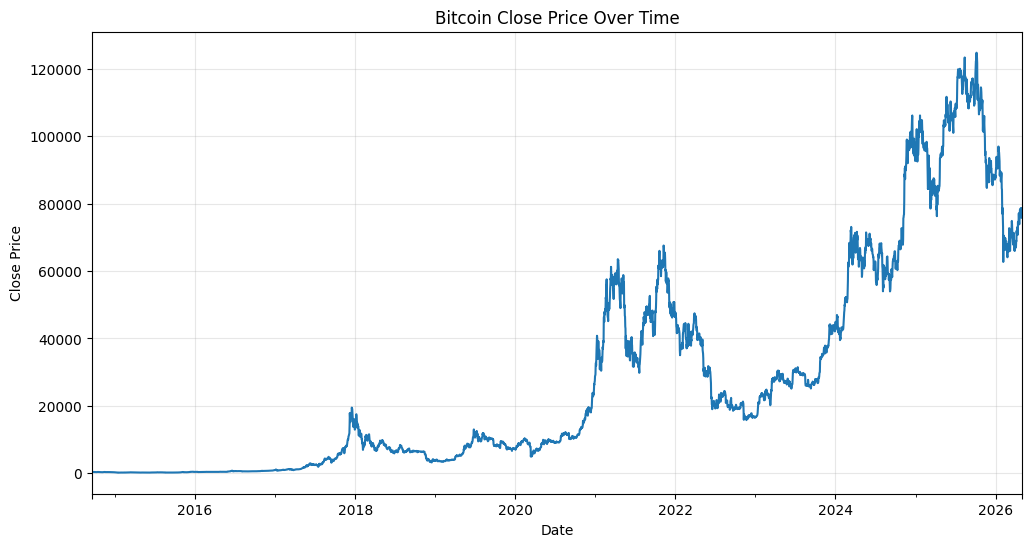

In [22]:
## Plot the stock
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
BTC_Close.plot()
plt.grid(True, alpha = 0.3)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Bitcoin Close Price Over Time')
plt.show()

In [23]:
## Fit an XGBoost?
#### we can use the sliding window approach
#### Tensorflow has a function TimeSeriesGenerator
X, y = make_windows(BTC_Close.values, window_size=4, horizon=1)

In [24]:
X

array([[  457.33401489,   424.44000244,   394.79598999,   408.9039917 ],
       [  424.44000244,   394.79598999,   408.9039917 ,   398.8210144 ],
       [  394.79598999,   408.9039917 ,   398.8210144 ,   402.15200806],
       ...,
       [77612.015625  , 78657.5390625 , 77366.625     , 76350.671875  ],
       [78657.5390625 , 77366.625     , 76350.671875  , 75776.1328125 ],
       [77366.625     , 76350.671875  , 75776.1328125 , 76304.3203125 ]])

In [25]:
y

array([  398.8210144 ,   402.15200806,   435.79098511, ...,
       75776.1328125 , 76304.3203125 , 78532.4765625 ])

In [26]:
X.shape

(4241, 4)

In [27]:
## Use Pandas for sliding window

df = pd.concat([BTC_Close.shift(4), BTC_Close.shift(3), BTC_Close.shift(2), BTC_Close.shift(1), BTC_Close], axis = 1)
df.columns = ['t-4', 't-3', 't-2', 't-1', 't']
df.dropna(inplace = True)
df.head()

,t-4,t-3,t-2,t-1,t
Date,,,,,
2014-09-21 00:00:00+00:00,457.334015,424.440002,394.795990,408.903992,398.821014
2014-09-22 00:00:00+00:00,424.440002,394.795990,408.903992,398.821014,402.152008
2014-09-23 00:00:00+00:00,394.795990,408.903992,398.821014,402.152008,435.790985
2014-09-24 00:00:00+00:00,408.903992,398.821014,402.152008,435.790985,423.204987
2014-09-25 00:00:00+00:00,398.821014,402.152008,435.790985,423.204987,411.574005


In [28]:
## SPLITTING DATA
#### CANT BE DONE RANDOMLY
train_df = df[:'2025-12-31']
test_df = df['2026-01-01':]

X_train = train_df.drop('t', axis = 1)
y_train = train_df['t']
X_test = test_df.drop('t', axis = 1)
y_test = test_df['t']

In [29]:
from xgboost import XGBRegressor

## instance
xgb = XGBRegressor()

## fit
xgb.fit(X_train, y_train)

## predict
y_pred_xgb = xgb.predict(X_test)

In [30]:
## Check performance: R2 and RMSE
from sklearn.metrics import r2_score, root_mean_squared_error

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print("R2:", r2_xgb)
print("RMSE:", rmse_xgb)

R2: 0.8914144800132106
RMSE: 3105.496964255538


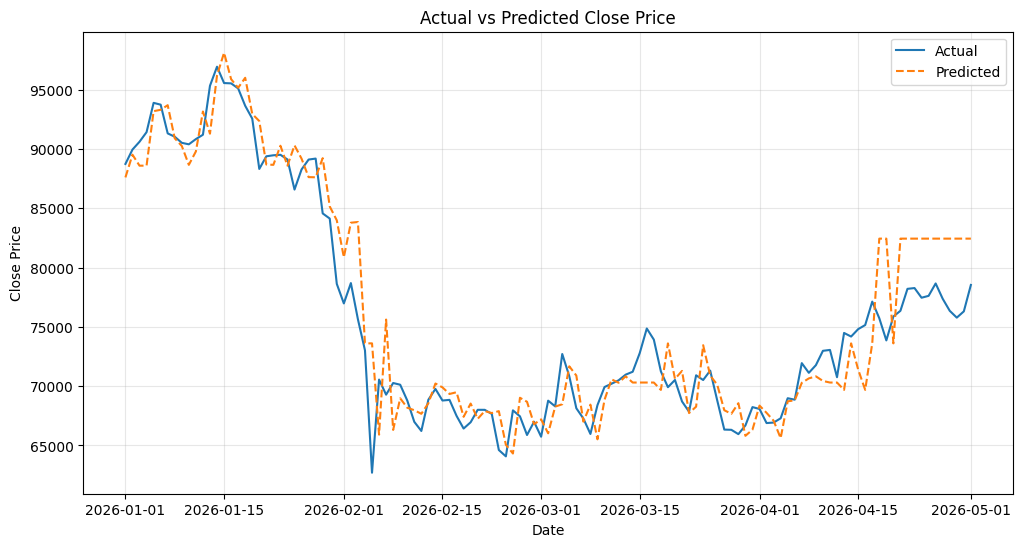

In [31]:
## Plot actual vs predicted

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_xgb, label='Predicted', linestyle = "--")
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.title('Actual vs Predicted Close Price')
plt.show()

In [32]:
## RANDOM FOREST






In [38]:
## Simple RNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator ## we do not need but we need a tensor
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


## 1) Standardize (normalize)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) ## use .transform on X_test to avoid data leakage
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

## 2) Network
### INPUT LAYER
model = Sequential()
model.add(Input(shape = (X_train_scaled.shape[1], 1)))

### RNN LAYER WITH DROPOUT
model.add(SimpleRNN(units = 64, activation = 'tanh', return_sequences = False)) ## if you want another SimpleRNN layer use return_sequences = True
model.add(Dropout(0.2))

### FEED-FORWARD ARCHITECTURE WITH DROPOUT
model.add(Dense(16, activation = 'relu'))
model.add(Dropout(0.2))

### OUTPUT LAYER
model.add(Dense(1))

### SUMMARY
model.summary()

### COMPILE
model.compile(optimizer = Adam(learning_rate = 0.001), loss = "mse")

### EARLY STOPPING
early_stopping = EarlyStopping(monitor = "val_loss", patience = 5, restore_best_weights = True)

### FIT
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.1,
    callbacks = [early_stopping]
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0046 - val_loss: 6.1376e-04
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024 - val_loss: 0.0124
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - val_loss: 5.5322e-04
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012 - val_loss: 4.4777e-04
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 6.3614e-04
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 5.0995e-04
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - val_loss: 3.5777e-04
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 0.0020
Epoch 12/100
116/

In [39]:
## Performance; R2 and RMSE
y_pred_rnn = model.predict(X_test_scaled)
y_pred_rnn = scaler_y.inverse_transform(y_pred_rnn)

r2 = r2_score(y_test, y_pred_rnn)
rmse = root_mean_squared_error(y_test, y_pred_rnn)

print("R2:", r2)
print("RMSE:", rmse)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
R2: 0.9353383833193523
RMSE: 2396.4503226822885


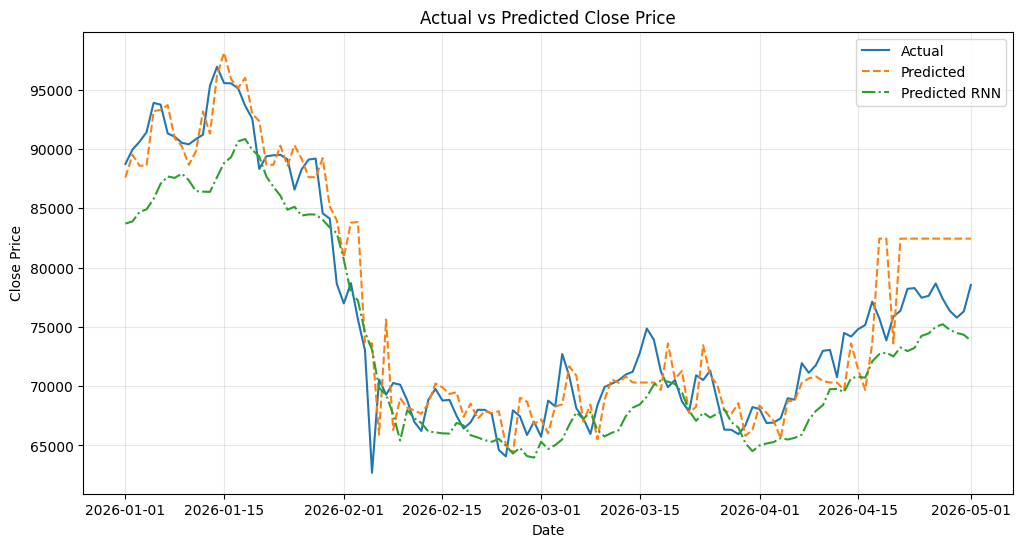

In [35]:
## Plot actual vs predicted

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_xgb, label='Predicted XGBoost', linestyle = "--")
plt.plot(y_test.index, y_pred_rnn, label='Predicted RNN', linestyle = "-.")
plt.plot(y_test.index, y_pred_cnn, label='Predicted CNN', linestyle = ":")
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.title('Actual vs Predicted Close Price')
plt.show()

In [36]:
## CNN Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Reshape data for CNN input (samples, timesteps, features)
# Current X_train_scaled shape: (samples, window_size) e.g., (4120, 4)
# We need (samples, window_size, 1) as there is 1 feature per timestep in this univariate case
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)


### Define CNN Model
cnn_model = Sequential()
cnn_model.add(Input(shape=(X_train_cnn.shape[1], 1))) # Input layer with shape (timesteps, features)
cnn_model.add(Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'))
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Flatten()) # Flatten the output for the Dense layers
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(1)) # Output layer for regression

cnn_model.summary()

### Compile CNN
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

### Early Stopping
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

### Fit CNN
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_cnn],
    verbose=0
)

## Performance: R2 and RMSE for CNN
y_pred_cnn_scaled = cnn_model.predict(X_test_cnn)
y_pred_cnn = scaler_y.inverse_transform(y_pred_cnn_scaled)

r2_cnn = r2_score(y_test, y_pred_cnn)
rmse_cnn = root_mean_squared_error(y_test, y_pred_cnn)

print("CNN R2:", r2_cnn)
print("CNN RMSE:", rmse_cnn)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
CNN R2: 0.9383971894178078
CNN RMSE: 2339.081827172361


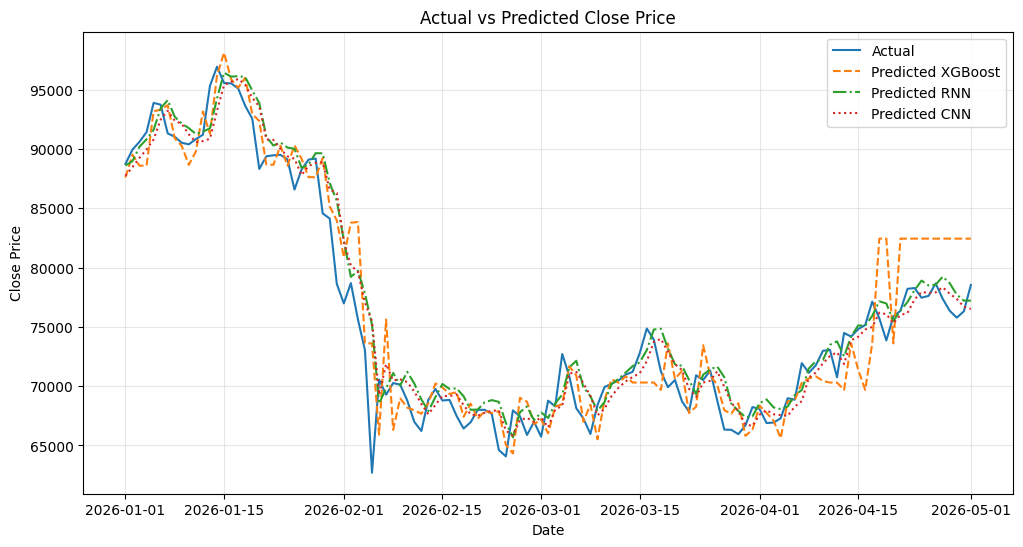

In [40]:
## Plot actual vs predicted

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_xgb, label='Predicted XGBoost', linestyle = "--")
plt.plot(y_test.index, y_pred_rnn, label='Predicted RNN', linestyle = "-.")
plt.plot(y_test.index, y_pred_cnn, label='Predicted CNN', linestyle = ":")
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.title('Actual vs Predicted Close Price')
plt.show()

---

# 6. Limitations of simple RNNs

Simple RNNs can struggle with:
- long-term dependencies
- vanishing gradients
- slow or unstable training

More advanced alternatives include:
- LSTM
- GRU
- attention-based models
- temporal CNNs

## Practice 6A

Why might a simple RNN struggle if the important pattern happened many time steps ago?

**Your response here:**  


Because of vanishing gradients.


---

# 7. Quiz-style review

Answer the following:

1. What is a sliding window?
2. What does horizon mean?
3. What is the hidden state in an RNN?
4. For RNN input shape `(samples, time_steps, features)`, what does each dimension mean?
5. Why should train/test splits for time series usually avoid random shuffling?
6. What is one limitation of a simple RNN?

**Your responses here:**  
1.  
2.  
3.  
4.  
5.  
6.

## Quick self-check

Suggested answers:
- A sliding window turns a sequence into supervised input-target examples.
- Horizon is how far ahead we predict.
- The hidden state carries information from previous time steps.
- Samples = number of windows, time_steps = length of each window, features = variables at each time step.
- Shuffling can leak future information into the training set.
- Simple RNNs can struggle with long-term dependencies and vanishing gradients.